## Машинное обучение 1, ПМИ ФКН ВШЭ

## Практическое домашнее задание 1

### Общая информация

Дата выдачи: 25.01.2026

Мягкий дедлайн: 23:59MSK 08.02.2026

Жесткий дедлайн: 23:59MSK 14.02.2026

### О задании

Задание состоит из двух разделов, посвященных работе с табличными данными с помощью библиотеки `polars` и визуализации с помощью `matplotlib`. В первом разделе вам предстоит выполнить базовые задания с помощью вышеуказанных библиотек, а во втором распределить студентов по курсам. Баллы даются за выполнение отдельных пунктов. Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании.

Задание направлено на освоение jupyter notebook (будет использоваться в дальнейших заданиях), библиотек `polars` и `matplotlib`.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов без учёта бонусов. Сдавать задание после жёсткого дедлайна нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Устная проверка. Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно получить у семинариста или ассистента. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате `homework-practice-01-polars-Username.ipynb`, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

Оценка: xx.

## 0. Введение

Сейчас мы находимся в jupyter-ноутбуке (или ipython-ноутбуке). Это удобная среда для написания кода, проведения экспериментов, изучения данных, построения визуализаций и других нужд, не связанных с написанием production-кода.

Ноутбук состоит из ячеек, каждая из которых может быть либо ячейкой с кодом, либо ячейкой с текстом размеченным и неразмеченным. Текст поддерживает markdown-разметку и формулы в Latex.

Для работы с содержимым ячейки используется *режим редактирования* (*Edit mode*, включается нажатием клавиши **Enter** после выбора ячейки), а для навигации между ячейками используется *командный режим* (*Command mode*, включается нажатием клавиши **Esc**). Тип ячейки можно задать в командном режиме либо с помощью горячих клавиш (**y** to code, **m** to markdown, **r** to edit raw text), либо в меню *Cell -> Cell type*.

После заполнения ячейки нужно нажать *Shift + Enter*, эта команда обработает содержимое ячейки: проинтерпретирует код или сверстает размеченный текст.

In [80]:
# ячейка с кодом, при выполнении которой появится output
2 + 2

4

Ячейка с неразмеченным текстом.

Попробуйте создать свои ячейки, написать какой-нибудь код и текст какой-нибудь формулой.

In [81]:
print("Sokolov = ml")

Sokolov = ml


[Здесь](https://athena.brynmawr.edu/jupyter/hub/dblank/public/Jupyter%20Notebook%20Users%20Manual.ipynb) находится <s>не</s>большая заметка о используемом языке разметки Markdown. Он позволяет:

0. Составлять упорядоченные списки
1. Выделять *текст* <s>при</s> **необходимости**
2. Добавлять [ссылки](http://imgs.xkcd.com/comics/the_universal_label.png)


* Составлять неупорядоченные списки

Делать вставки с помощью LaTex:
    
$
\left\{
\begin{array}{ll}
x = 16 \sin^3 (t) \\
y = 13 \cos (t) - 5 \cos (2t) - 2 \cos (3t) - \cos (4t) \\
t \in [0, 2 \pi]
\end{array}
\right.$

А ещё можно вставлять картинки, или гифки, или что захотите:

<img src="https://i.imgur.com/k5df8lX.gif" width="400px">



### Google Colab

Что за колаб?

**Google Colab (Colaboratory)** это **Jupyter Notebook + Cloud + Google Drive.**

Компания Google предоставляет возможность бесплатно запускать ноутбуки (предварительно загрузив их на свой гугл-диск) прямо в облаке. При этом вам не требуется установка никаких пакетов на свою машину, а работать можно прямиком из браузера. Вот ссылка:

https://colab.research.google.com

При использовании вы увидите много сходств с jupyter ноутбуком. Одним из преимуществ является доступность GPU, соответствующую опцию можно активировать в настройках сервиса. При желании вы сможете найти в интернете много туториалов по использованию или разобраться самостоятельно =)

### Kaggle

Альтернативой является **Kaggle**, он же площадка для самых разных соревнований по машинному обучению

Он, как и колаб, предоставляет бесплатный GPU, и даже не один, с чётким лимитом в 30 часов в неделю (colab может его внезапно отобрать, kaggle - нет) более мощные CPU с большим числом ядер, и больше Гб ОЗУ (раз так в 2.5)

https://www.kaggle.com

К сожалению мир не идеален, недостатки следующие:
- необходимость загружать датасеты через специальную кнопочку
- невозможность использовать свои скрипты и модули :(
- нужно тыкать техподдержку, чтобы создать аккаунт из России

## 1. Табличные данные и Polars [4 балла]

Сперва повторим, почему `polars` такой клёвый, если вы не были на семинаре, либо не хотите с ним ознакомиться

Эта версия домашки предполагает, что вы уже являетесь уверенным пользователем `pandas` и знакомы с датафреймами, как они устроены и как ими манипулировать. Библиотека `polars` основана на тех же концептах.

Главные достоинства, которые чуть позже продемонстрируем:
- он написан на Rust, поэтому почти все операции в нём выполняются значительно быстрее, есть распараллеливание из коробки, автоматическая оптимизация запросов и пр
- он позволяет работать с данными, которые не помещаются в оперативку, с этим поможет `pl.LazyFrame` и параметр `engine`/`streaming`
- конечно же имеются дополнительные функции, которых в `pandas` нет, но очень хочется, например агрегации с расширяющимся окном, произвольные оконные функции и прочее, для этого есть крайне гибкая штука `pl.Expr`

Подробнее можете прочитать на [любом](https://habr.com/ru/articles/710240/) [ресурсе](https://realpython.com/polars-python/), [посвящённом](https://blog.jetbrains.com/pycharm/2024/07/polars-vs-pandas/) [`polars`](https://habr.com/ru/companies/spectr/articles/738766/)

В этой части потребуется выполнить несколько небольших заданий. Можно пойти двумя путями: сначала изучить материалы, а потом приступить к заданиям, или же разбираться "по ходу". Выбирайте сами

Если не понятно, как вызывать конкретный метод, обратитесь к материалам ниже. Имейте в виду, что синтаксис `polars` отличается от привычного нампаевского.
Скорее всего все ваши самые извращённые фантазии уже как-то реализованы в `polars`, поэтому читайте внимательно. Ну и конечно гуглить не запрещено, но желательно прикладывать источник

Материалы:
1. [Getting started](https://docs.pola.rs/user-guide/getting-started/#reading-writing) из официального руководства
2. [Документация](https://docs.pola.rs/api/python/stable/reference/index.html) со всем необходимым
3. [Модификация для Data Science](https://polars-ds-extension.readthedocs.io/en/latest/index.html), вам скорее всего не понадобится в данном задании, но имейте в виду

Многие из заданий можно выполнить несколькими способами. Не существуют единственно верного, но попробуйте максимально задействовать арсенал polars и ориентируйтесь на простоту и понятность вашего кода. Мы не будем подсказывать, что нужно использовать для решения конкретной задачи, попробуйте находить необходимый функционал сами (название метода чаще всего очевидно)

In [82]:
# поларс относительно молодой, имейте в виду, что что-то может сломаться, если будете менять версию
!uv add -qU hvplot xlsx2csv polars seaborn

In [83]:
import polars as pl
import gc
import seaborn as sns
import matplotlib.pyplot as plt

Скачаем данные:

In [84]:
# !wget  -O 'end_seminar.xlsx' -q 'https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0'

Для пользователей Windows: скачайте файл самостоятельно и поместите его в папку с тетрадкой. Или попробуйте один из следующих вариантов:

In [85]:
# !powershell iwr -outf somefile https://somesite/somefile

In [86]:
# !pip install wget
# import wget
# wget.download('https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0', 'end_seminar.xlsx')

### 📌 **Обязательно прочитайте блок ниже**

> Пандасом и нампаем пользоваться неельзяя... Совсем, методами `to_pandas()` и `to_numpy()` тоже

> В первой части задания (до раздела "Распределение студентов по курсам") использование циклов запрещается и повлечет за собой снижение оценки. Во второй уже можно, но с оговорками, о чём ниже

> Циклами в данном случае считается `for`, `while` и `map`-методы `polars`, где можно использовать лямбда-функцию. Главным образом `map_elements` и его аналоги.
И как правило, всё то, что не умеет делать `pl.LazyFrame` - список [здесь](https://docs.pola.rs/api/python/stable/reference/lazyframe/index.html). Мотивация следующая - используя встроенные функции и методы, `polars` может оптимизировать ваш запрос и провести все нужные манипуляции, прежде чем сериализовать и вывести ответ (за некоторыми исключениями), поэтому важно научиться с этим управляться

> Чтобы сделать выбор `polars` осмысленным, мы немножко модифицируем исходный датасет. Он будет больше в несколько раз и может не влезть в память, если у вас меньше 8 Гб, а с учётом преобразований может потребоваться до 64 Гб! Не пренебрегайте возможностями `pl.LazyFrame`. Его использование не обязательно, но может сильно облегчить вам жизнь

> Трансформировать датасет `df` можно, как только это потребуется по условию (таких пунктов всего 2), на всякий случай поставим значок 🔄

> Если небрежно обращаться с методами `polars`, вы рискуете крашнуть ядро, взорвать компутер, потерять рассудок... Если вдруг у вас есть тачка или хотите подебажить на исходном датасете, то пожалуйста, но помните про условия выше. В частности, при работе в колабе после ряда пунктов может остаться всякий мусор, не забывайте убирать за собой и пользоваться `gc.collect()`

> Все, что не запрещено выше, разрешено

> Гарантируется, что задание можно выполнить, имея лишь ресурсы Google Colab (бесплатные), удачи ( ͡° ͜ʖ ͡°)

Для каждой задачи из этого раздела вы должны написать код для получения ответа, а также дать текстовый ответ, если он предполагается.

На некоторые вопросы вы можете получить путём пристального взгляда на таблицу, но это не будет засчитываться. Вы в любом случае должны получить ответ с помощью кода.

### 🐻 Бонус polars. [1.5 балла]
Бонус за использование `polars` равен вашей оценке за дз, умноженной на коэффициент 1.15, не считая бонуса за отсутствие циклов, он прибавляется отдельно. Поэтому даже если сделали не всё, не отчаивайтесь!

**Максимальная оценка за дз - 10 * 1.15 (polars) + 1 (бонус без циклов)**

#### 0. Ещё пара красивых слов

Первые несколько манипуляций мы сделаем за вас, а заодно поясним, в чём тут нюанс

In [87]:
# читаем датафрейм
initial_df = pl.read_excel("end_seminar.xlsx", engine="xlsx2csv")
print(initial_df.shape[0], "rows")
print(initial_df.estimated_size("mb"), "mb")

429 rows
0.18347549438476562 mb


Как видим, он достаточно маленький. С такими объёмами выбор библиотеки это чисто вкусовщина. Давайте немного поднимем ставки

In [88]:
def repeat_df(df: pl.DataFrame | pl.LazyFrame, n: int = 2) -> pl.LazyFrame:
    return (
        df.lazy()
        .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())
        .join(df.lazy(), on="timestamp", how="left")
    )

Для работы с датафреймами, которые в память не влезают, нам понадобится объект `pl.LazyFrame`. Он представляет из себя схему выполнения вашего запроса, который оптимизируется, бьётся на батчи и параллелится под капотом через StreamingAPI, что для нас просто идеально. Перевести объект туда можно через метод `lazy`, обратно через `collect`. Учтите, что `streaming=True` работает не со всеми операциями, применяйте с умом, это можно проверить через `pl.LazyFrame.explain(streaming=True)`

In [89]:
repeat_n = 2

repeated_df = repeat_df(initial_df, repeat_n)
print("Schema")
print(repeated_df.explain(streaming=True, optimized=True))

Schema
LEFT JOIN:
LEFT PLAN ON: [col("timestamp")]
  SELECT [col("timestamp").unique().sort(asc).repeat_by([dyn int: 2]).explode()]
    DF ["timestamp", "id", "rating", "group_22", ...]; PROJECT["timestamp"] 1/16 COLUMNS
RIGHT PLAN ON: [col("timestamp")]
  DF ["timestamp", "id", "rating", "group_22", ...]; PROJECT["timestamp", "id", "rating", "group_22", ...] 16/16 COLUMNS
END LEFT JOIN


/var/folders/ly/hh8yqfmx3r122jb_dvxjy8qr0000gn/T/ipykernel_54511/2548353322.py:4: DeprecationWarning: `Expr.flatten()` is deprecated and will be removed in version 2.0. Use `Expr.list.explode(keep_nulls=False, empty_as_null=False)` instead.
  .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())
/var/folders/ly/hh8yqfmx3r122jb_dvxjy8qr0000gn/T/ipykernel_54511/2973500786.py:5: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  print(repeated_df.explain(streaming=True, optimized=True))


In [90]:
# как видим, повторы работают
repeated_df = repeated_df.collect()
assert repeated_df.shape[0] == initial_df.shape[0] * repeat_n
print(repeated_df.shape[0], "rows")
print(repeated_df.estimated_size("mb"), "mb")

858 rows
0.3668785095214844 mb


Теперь ещё интереснее. Если бы наш датасет был не в 2 раза больше, а в 100000 раз, что бы мы делали? К счастью для нас, поларс может уместить 300кк строк всего лишь в 512Мб, и это даже не прикол, но работать с этим придётся немного иначе

In [91]:
N = 80000

df = repeat_df(initial_df, N)
print(initial_df.estimated_size("gb") * N, "gb")

14.334022998809814 gb


/var/folders/ly/hh8yqfmx3r122jb_dvxjy8qr0000gn/T/ipykernel_54511/2548353322.py:4: DeprecationWarning: `Expr.flatten()` is deprecated and will be removed in version 2.0. Use `Expr.list.explode(keep_nulls=False, empty_as_null=False)` instead.
  .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())


Поэтому даже такая тривиальная задача, как подсчёт строк становится уже не такой простой. Про это и будет дз

In [92]:
try:
    print(df.shape[0], "rows")
except AttributeError:
    print("ой, не получилось...")

# df.collect().shape[0] # тоже можно, если влезет
# len(df.collect().to_pandas()) # а такое может крашнуть ядро, попробуйте, хехе...

ой, не получилось...


In [93]:
def lazy_len(df: pl.LazyFrame) -> int:
    return df.select(pl.len()).collect().item()


rows = lazy_len(df)  # намного экономнее, потому что оптимизировано под капотом
assert rows == initial_df.shape[0] * N
print(rows, "rows")

34320000 rows


Далее нужно работать с увеличенным датафреймом `df`

#### 1. [0.5 баллов] Выведите 3 последних строки

Посмотрите на данные и скажите, что они из себя представляют, сколько в таблице строк, какие столбцы? (на это не надо отвечать, просто подумайте об этом)

In [94]:
df.tail(3).collect()

timestamp,id,rating,group_22,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
str,str,i64,i64,i64,str,str,str,str,str,str,str,f64,str,str,bool
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null


### Ответьте на вопросы:
1. Сколько было уникальных пользователей из групп 22-го года набора, а сколько из групп 21-го года?

In [95]:
res_22 = df.filter(pl.col("group_22").is_not_null()).select(pl.n_unique("id")).collect()

In [96]:
res_21 = df.filter(pl.col("group_21").is_not_null()).select(pl.n_unique("id")).collect()

In [97]:
print("2021:", res_21)
print("2022:", res_22)

2021: shape: (1, 1)
┌─────┐
│ id  │
│ --- │
│ u32 │
╞═════╡
│ 159 │
└─────┘
2022: shape: (1, 1)
┌─────┐
│ id  │
│ --- │
│ u32 │
╞═════╡
│ 259 │
└─────┘


2. Есть ли среди объединенного множества 3-го и 4-го курса уникальные студенты с равными перцентилями?

In [98]:
same = (
    df.select(["id", "percentile"])
    .drop_nulls(["id", "percentile"])
    .group_by("percentile")
    .agg(pl.col("id").n_unique().alias("agreg id"))
    .collect()
)

In [99]:
same.filter(pl.col("agreg id") > 1).select(pl.len())

len
u32
71


#### 2. [0.5 балла] Есть ли в данных пропуски? В каких колонках? Сколько их в каждой из этих колонок?

Уникальных или нет - не столь важно

In [100]:
df.null_count().collect()

timestamp,id,rating,group_22,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,12720000,32240000,0,0,0,3840000,3840000,3840000,0,0,21600000,21600000,20320000


In [101]:
df.filter(pl.col("group_22").is_not_null()).group_by("blended").agg().collect()

blended
str
null


🔄 Преобразуйте датасет - заполните пропуски пустой строкой для строковых колонок, нулём для числовых и False для булевых (постарайтесь избежать перечисления названий всех столбцов). Опирайтесь не на смысл столбцов, а на текущий тип данных.

In [102]:
df = df.cast({"group_22": pl.String})
df = df.with_columns(
    pl.col(pl.Int64, pl.Float64).fill_null(0),
    pl.col(pl.Boolean).fill_null(False),
    pl.col(pl.String).fill_null(""),
)

In [103]:
df.collect_schema()

Schema([('timestamp', String),
        ('id', String),
        ('rating', Int64),
        ('group_22', String),
        ('is_mi', Int64),
        ('fall_1', String),
        ('fall_2', String),
        ('fall_3', String),
        ('spring_1', String),
        ('spring_2', String),
        ('spring_3', String),
        ('is_first_time', String),
        ('percentile', Float64),
        ('group_21', String),
        ('blended', String),
        ('is_ml_student', Boolean)])

#### 3. [0.5 балла] Посмотрите повнимательнее на колонку 'is_first_time'.

Каково процентное соотношение ответов? Сколько из них "Нет"?

In [104]:
100 * df.select((pl.col("is_first_time") == "Нет").sum()).collect() / df.select(
    pl.count()
).collect()

/var/folders/ly/hh8yqfmx3r122jb_dvxjy8qr0000gn/T/ipykernel_54511/292709743.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count()


is_first_time
f64
5.128205


Посмотрите на колонку `timestamp` - верно ли, что датафрейм отсортирован по ней?

In [105]:
df = df.with_columns(
    pl.col("timestamp").str.strptime(
        pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False
    )
)

In [106]:
df.select((pl.col("timestamp") < pl.col("timestamp").shift(-1)).any()).collect()

timestamp
bool
true


### Нет не верно

🔄 Оставьте только самую позднюю версию обращений студентов, уберите колонку `is_mi` (она нам не пригодится в дальнейшем) и сохраните изменения. Дубли оставлять тоже не нужно

<i>Обращения со значением "Нет" в 'is_first_time' могут быть как повторными, так и первичными, поскольку поле заполняли сами студенты.</i>

In [107]:
df_new = df.drop("is_mi").sort("timestamp").unique(subset=["id"], keep="last").collect()

In [108]:
list(df_new.collect_schema())

['timestamp',
 'id',
 'rating',
 'group_22',
 'fall_1',
 'fall_2',
 'fall_3',
 'spring_1',
 'spring_2',
 'spring_3',
 'is_first_time',
 'percentile',
 'group_21',
 'blended',
 'is_ml_student']

#### 4. [0.5 балла] Какие  blended-курсы для четверокурсников существуют? На какой blended-курс записалось наибольшее количество студентов?  На каком из blended-курсов наименьший средний перцентиль студентов, подавших заявку (выведите этот курс и количество студентов на нем)?

In [109]:
(
    df_new.lazy()
    .filter(pl.col("blended") != "")
    .group_by("blended")
    .agg(pl.col("id").alias("ids"))
    .with_columns(pl.col("ids").list.len().alias("count"))
    .select(["blended", "count"])
    .collect()
)

blended,count
str,u32
"""ML System Design""",38
"""Введение в дифференциальную ге…",13
"""Протоколы доказательств с нуле…",44
"""Продуктовый подход к анализу д…",25
"""Соревновательный анализ данных""",26
"""Безопасность систем на базе LL…",13


#### 5. [1 балл] Выясните, есть ли студенты с абсолютно одинаковыми предпочтениями по всем курсам.

Для этого сформируйте таблицу, где для каждого возможного набора курсов посчитано количество студентов, выбравших такой набор, и оставьте только строки где это количество больше 1. Формировать варианты, которые не представлены ни одним студентом изначально, не требуется.


В данном случае набор курсов задается упорядоченным множеством ('fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'). Элемент blended будет нулевым для 3-го курса.

In [110]:
df_new.group_by(
    "fall_1", "fall_2", "fall_3", "spring_1", "spring_2", "spring_3", "blended"
).agg(pl.col("id").n_unique().alias("count")).filter(pl.col("count") > 1)

fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,blended,count
str,str,str,str,str,str,str,u32
"""Дизайн систем""","""Операционные системы 2""","""Основы информационного поиска""","""Промышленное программирование …","""Децентрализованные системы""","""Методы сжатия и передачи медиа…","""Протоколы доказательств с нуле…",2
"""Системы баз данных""","""Системы баз данных""","""Системы баз данных""","""Компьютерные сети""","""Компьютерные сети""","""Компьютерные сети""","""""",9
"""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Язык SQL""","""Компьютерные сети""","""Компьютерные сети""","""Компьютерные сети""","""""",2
"""Системы баз данных""","""Разработка микросервисов на Go""","""Основы разработки компьютерных…","""Язык программирования Go""","""Компьютерные сети""","""Промышленное программирование …","""""",2
"""Системы баз данных""","""Разработка микросервисов на Go""","""Операционные системы 2""","""Компьютерные сети""","""Промышленное программирование …","""Машинное обучение 2""","""""",2
…,…,…,…,…,…,…,…
"""Дизайн систем""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Децентрализованные системы""","""Методы сжатия и передачи медиа…","""Теория и практика онлайн-экспе…","""Протоколы доказательств с нуле…",2
"""Системы баз данных""","""Операционные системы 2""","""Разработка микросервисов на Go""","""""","""""","""""","""""",2
"""Системы баз данных""","""Разработка микросервисов на Go""","""Распределенные системы""","""Компьютерные сети""","""Компьютерные сети""","""Компьютерные сети""","""""",4


#### 6. [0.5 балла] Найдите курсы по выбору, на которые записывались как студенты 22-го года набора, так и студенты 21-го года.

Методом исключения найдите курсы, которые предлагались только студентам 22-го года и только студентам 21-го года.

In [ ]:
course_cols = [
    "fall_1",
    "fall_2",
    "fall_3",
    "spring_1",
    "spring_2",
    "spring_3",
    "blended",
]

ans = (
    df_new.lazy()
    .select(["id", "group_21", "group_22", *course_cols])
    .with_columns(
        cohort=pl.when(
            pl.col("group_21").is_not_null()
            & (pl.col("group_21") != "")
            & (pl.col("group_21") != "")
        )
        .then(pl.lit("21"))
        .when(
            pl.col("group_22").is_not_null()
            & (pl.col("group_22") != "")
            & (pl.col("group_22") != "")
        )
        .then(pl.lit("22"))
        .otherwise(None)
    )
    .unpivot(
        index=["id", "cohort"],
        on=course_cols,
        variable_name="slot",
        value_name="course",
    )
    .filter(pl.col("course").is_not_null() & (pl.col("course") != ""))
    .select(["id", "cohort", "course"])
    .group_by("cohort")
    .agg("course")
    .collect()
)["course"]

# NOTE: сделано с помощь gpt (долго с unpivot мучился)

In [ ]:
a21 = ans[0].unique()
a22 = ans[1].unique()

a21.filter(a21.is_in(a22))

cohort,course
str,list[str]


Видите ли вы что-то необычное в получившихся списках? (менять ничего не нужно, просто подумайте)

**Ответ:**



### Визуализации

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные. Здесь будут описаны ключевые правила оформления графиков для **всех** домашних заданий.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

В этом задании вы попробуете построить один из них. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если возможно сделать график интерактивным, это обычно того стоит - помогает решить проблемы с читаемостью;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
- сетка на графике помогает оценить значения в точках на глаз, это обычно полезно, поэтому лучше ее отрисовывать;
- если распределение на гистограмме имеет тяжёлые хвосты, лучше использовать логарифмическую шкалу.

Еще одна библиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

У `polars` уже есть встроенные инструменты для визуализации, в частности интерактивные на базе [hvplot](https://docs.pola.rs/user-guide/misc/visualization/#plotly) и [altair](https://docs.pola.rs/user-guide/misc/visualization). Из её преимуществ - хорошая производительность при работе с большими данными, есть поддержка самых популярных видов графиков, но синтаксис не самый удобный

#### 7. [0.5 балла] Постройте график (barplot) медианных перцентилей в зависимости от первого символа hex-кода id студента

Таким образом мы на глаз прикидываем, есть ли зависимость между, якобы, случайным id и значимым параметром. Если зависимость есть, и в дальнейшем мы будем сплитовать данные на тест и трейн по такому айдишнику без перемешивания, то можем допустить утечку, поэтому такие особенности важно отслеживать.

В графике явно задайте порядок столбцов по символам hex-алфавита (от 0 до f слева направо) и настройте отображение доверительных интервалов уровня **0.96**. Можно ли говорить о наличии проверяемой зависимости на основе визуальной информации?

/Users/gorsenkovegor/Projects/Study/ml-hw/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


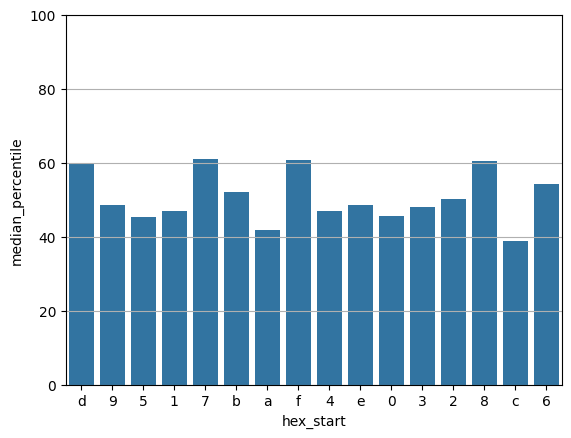

In [112]:
plot_data = (
    df_new.lazy()
    .select(pl.col("id").str.slice(0, 1).alias("hex_start"), pl.col("percentile"))
    .group_by("hex_start")
    .agg((100 * pl.col("percentile").median()).alias("median_percentile"))
    .collect()
)

ax = sns.barplot(plot_data, x="hex_start", y="median_percentile")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", which="major")
plt.savefig("percentile.pdf")

Сохраните график в формате pdf (так он останется векторизованным) или html (тогда останется интерактивным)

In [113]:
# NOTE: сделал в предыдущем

## 2. Распределение студентов по курсам. (6 баллов + 1 бонус)

#### **<span style="color:red">‼️ВНИМАТЕЛЬНО ИЗУЧИТЕ ТЕКСТ НИЖЕ‼️</span>.**

<span style="color:orange">Если во время выполнения заданий у вас возникнут вопросы - еще раз перечитайте текст целиком, скорее всего ответы уже содержатся в нем.</span>

Теперь вам нужно распределить студентов по осенним курсам по выбору, учитывая их предпочтения.

##**Алгоритм распределения студентов по курсам**:

1. Для каждой дисциплины формируется список тех, кто указал её первым приоритетом (если студент должен выбрать два курса по выбору, то для него дисциплины, которые он указал первым и вторым приоритетом, рассматриваются как дисциплины первого приоритета). Если желающих больше, чем мест (см ниже), то выбирается топ по перцентилю рейтинга.
2. На дисциплинах, где остались места после первой волны, формируются списки тех, кто выбрал их вторым приоритетом, и места заполняются лучшими по перцентилю рейтинга студентами. После этого проводится такая же процедура для дисциплин третьего приоритета.
3. Если студент не попал на необходимое количество курсов по итогам трёх волн, с ним связывается учебный офис и решает вопрос в индивидуальном порядке.

## ☝️ **Обращаем ваше внимание на следующие детали:**

### Особенности реализации алгоритма:

- Конкурс на каждый курс общий для 3-го (22-й год) и 4-го курса (21-й год), то есть список формируется из студентов обоих курсов.

- По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов).
  - Исключения:
    * Количественные финансы - 60
    * Промышленное программирование на Haskell - 60
    * Рекомендательные системы - 60
    * Глубинное обучение в обработке звука - 1000 (да да, не удивляйтесь! раньше и не такое было...)


- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп **21-го года специализации МОП** выбирают по 2 осенних и 2 весенних курса по выбору. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.
  - "Сдвиг" = приоритеты 2 и 3 становятся приоритетами 1 и 2, 3-й приоритет остается пустым.
  - Из-за совпадений первого и второго курса по выбору в прочих случаях двигать приоритеты не надо.


- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- В рамках своего решения вы можете считать, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.


### Я МОП и я люблю <s>Я</s>



**Принадлежность к <s> стойлу</s> специализации МОП определяется так:**

- 21-й год (4-й курс):
  * 211, 212, 213 - МОП; остальные - не МОП! 👎

- 22-й год (3-й курс)
  -  Студенты, у которых проставлен флаг в колонке `is_ml_student`.

### Рейтинг и перцентиль

#### Рейтинг

В столбце `'rating'` записана кредитно-рейтинговая сумма студента (грубо говоря, сумма оценок студента по всем его дисциплинам с весами (веса > 1) — чем дольше шла дисциплина, тем больше вес; подробности тут: https://www.hse.ru/studyspravka/rate/).

Чем больше курсов взял студент за период обучения, и чем лучше он их закрыл, тем выше его значение `'rating'`, соответственно, эта метрика возрастает по "качеству" студента.

#### Перцентиль

В столбце `'percentile'` записан перцентиль студента в рамках своего курса своей ОП.

Перцентиль студента X определяется следующим образом: "процент студентов, чьи результаты обучения лучше, чем у студента X". Соответственно, 0% -- лучший студент на потоке, $\to$ 100% -- худший студент на потоке, то есть метрика убывает по "качеству" студента.


Мы распределяем студентов по топу перцентиля, то есть по наименьшему перцентилю.


За прочими подробностями отправляем вас в ноутбук семинара.

### Требования к решению

- Постарайтесь воздержаться от использования циклов там, где это возможно. Допустимо итерироваться по <b>курсам</b>, на которые проводится отбор, и по <b>волнам</b> отбора. <i>Если вы придумаете, как обойтись без цикла по <b>курсам</b>, то можете получить **+1 бонусный балл** к итоговой оценке. <b>Дублирование кода не признается успешным избавлением от циклов</b></i>

- На выходе ожидается файл `res_fall.csv` с результатами распределения на осенние курсы по выбору. Файл должен быть следующего формата:

    * три столбца: ID, course1, course2
    
    * Если студент не попал на курс, но должен был, то вместо названия курса в ячейке должна быть строка "???"
    
    * Если студент должен выбрать только один курс, то в колонке course2 для него должна стоять строка "-"

    * Если студент должен выбрать два курса по выбору, то порядок в колонках course1 и course2 не важен.
    
    * Формат csv: для сохранения воспользуйтесь `df.to_csv('solution.csv', index=None)`

Для работы вам могут понадобиться следующие данные:

- Результаты опроса (вы уже использовали этот файл в первой части задания, но на всякий случай ссылка: https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0)


Кстати, убедитесь, что в данных больше нет пропусков, повторных записей и лишних колонок

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов

In [115]:
df = df_new
assert type(df) != pl.LazyFrame and type(df) == pl.DataFrame, "Датафрейм не собран"
assert df.shape == (418, 15), "В таблице остались повторы или потеряны данные"
assert df.null_count().sum_horizontal().item() == 0, "В таблице остались пропуски"

Если вы не получили `AssertionError`, то можете продолжать.

#### 1. [1 балл] Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе студента.

In [126]:
mop_21 = ["211", "212", "213"]

In [132]:
df = (
    df.lazy()
    .with_columns((1 + pl.col("group_21").is_in(mop_21)).alias("fall_count"))
    .collect()
)

Проверка:

In [131]:
col_name = "fall_count"  # insert your new column name as str

ids = [
    "bcca318e644999583156ff3ab9de3d6bd02295dcb166e39006568ffe9582207b",
    "edb64996c64421378537d941a77426a5a7bd84f9967ad9f523ca61386e5469ed",
    "5f96908e3ce5d84d693ddd79670d60cd1c6a02646aa779f46586a7699dda7c25",
    "0f137538a170b64258c0e10839cadc325e5f22fc5bb5fa9e20b7351f0a680366",
]

assert (df.filter(pl.col("id").is_in(ids)).sort("id")[col_name] == [2, 1, 1, 1]).all()

#### 2. [2 балла] Распределите студентов в соответствии с первым приоритетом

### Особенности реализации алгоритма:

- Конкурс на каждый курс общий для 3-го (22-й год) и 4-го курса (21-й год), то есть список формируется из студентов обоих курсов.

- По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов).
  - Исключения:
    * Количественные финансы - 60
    * Промышленное программирование на Haskell - 60
    * Рекомендательные системы - 60
    * Глубинное обучение в обработке звука - 1000 (да да, не удивляйтесь! раньше и не такое было...)


- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп **21-го года специализации МОП** выбирают по 2 осенних и 2 весенних курса по выбору. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.
  - "Сдвиг" = приоритеты 2 и 3 становятся приоритетами 1 и 2, 3-й приоритет остается пустым.
  - Из-за совпадений первого и второго курса по выбору в прочих случаях двигать приоритеты не надо.


- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- В рамках своего решения вы можете считать, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.


In [ ]:
# (￣^￣)ゞ
df_wave = (
    df.select(["id", "fall_1", "fall_2", "fall_3", "fall_count", "percentile"])
    .with_columns(
        pl.when(pl.col("fall_count") == 1)
        .then(pl.col("fall_1"))
        .otherwise(
            pl.concat_str(
                [pl.col("fall_1"), pl.lit(","), pl.col("fall_2")], separator=""
            )
        )
        .alias("pr1")
    )
    .with_columns(pl.col("pr1").str.split(",").alias("pr1_l"))
    .explode("pr1_l")
    .filter(pl.col("pr1_l") != "")
    .with_columns(pl.col("pr1_l").alias("course"))
)

df_wave = df_wave.with_columns(
    pl.when(
        pl.col("course").is_in(
            [
                "Количественные финансы",
                "Промышленное программирование на Haskell",
                "Рекомендательные системы",
            ]
        )
    )
    .then(pl.lit(60))
    .when(pl.col("course") == "Глубинное обучение в обработке звука")
    .then(pl.lit(1000))
    .otherwise(pl.lit(30))
    .alias("max")
)

df_wave_rank = df_wave.with_columns(
    pl.col("percentile").rank("ordinal", descending=False).over("course").alias("rank")
)

df_wave_x = df_wave_rank.filter(pl.col("rank") <= pl.col("max")).select(
    ["id", "course"]
)

df_wave_x

id,course
str,str
"""0ffab253552cccd8b0be91ec9dea9d…","""Операционные системы 2"""
"""b41c8c232e79a87b8df908c9df6cd5…","""Введение в платформы данных"""
"""b315b92935edc5a3e9286170b5a534…","""Байесовские методы в машинном …"
"""b315b92935edc5a3e9286170b5a534…","""Глубинное обучение для текстов…"
"""cb2cfbddf163cc61d9c4967e180124…","""Операционные системы 2"""
"""cb2cfbddf163cc61d9c4967e180124…","""Дизайн систем"""
"""194eaf21b52441c75d57fff447a512…","""Основы тензорных вычислений"""
"""747a049cf1602e1c0331483ae1e6a4…","""Основы информационного поиска"""
"""acb47d76f3aa4524fba24b7e9feabe…","""Байесовские методы в машинном …"


Сверьте назначенные вами на первой волне курсы с эталоном. Для этого преобразуйте данные о назначенных курсах, приведя их в разрез "по студенту" (подробнее см в докстринге тест-функции), **переведите в pandas.DataFrame** и передайте в функцию 'check_first_wave_assignments'. Если функция не выбросила Exception, то всё хорошо!

**Обратите внимание: здесь обрабатывать детали условия касающиеся ответов `'???'` и `'-'` из требований к решению
обрабатывать не нужно!**

Трансформацию датасета (создание колонок `'course1'` и `'course2'`) советуем выделить в отдельную функцию, поскольку она понадобится вам далее при сдаче результатов в тестирующую систему.

In [ ]:
import pandas as pd

!wget  -O 'task_2_check.csv' -q 'https://www.dropbox.com/scl/fi/mxmp3b8ecssaei78sk4sp/task_2_check.csv?rlkey=uccmkaeo0zgv78pp3czs0s122&st=gr7s4m5u&dl=0'

check_df = pd.read_csv('./task_2_check.csv')

Если открытие check_df кинуло Exception, проверьте, что файл лежит в той же директории, из которой запущено ядро (kernel) вашего ноутбука (в его current working directory).

*Стандартно файл должен скачиваться как раз туда, но вдруг у вас что-то пошло не так*

In [ ]:
from pandas.testing import assert_frame_equal
from collections import Counter


def check_first_wave_assignments(assignments: pd.DataFrame) -> None:
    """
    assignments - pandas DataFrame с колонками ['ID', 'course1', 'course2', 'fall_course_num']. Одна строка - один студент.
    - 'ID' - id студента (не объект индекса!)
    - 'course1', 'course2' - названия курсов, назначенные студенту в первую волну.
    Если один из курсов не назначен (вне зависимости от того, должен ли был быть назначен), то None.
    - 'fall_course_num' - число осенних курсов, которые должен выбрать студент.
    """

    def course_columns_to_set_column(row: pd.DataFrame):
        result = Counter()

        for column in ["course1", "course2"]:
            if not pd.isna(row[column]) and row[column] is not None:
                result[row[column]] += 1
        return result

    ANSWER_SOURCE = "task_2_check.csv"

    ALTERNATIVES = {
        "cdb87f7b15495e514eb481230b44540c6b0cfeb347c991f06b1e361fcdef0c0b": [
            Counter(
                {
                    "Глубинное обучение для текстовых данных",
                    "Байесовские методы в машинном обучении",
                }
            ),
            Counter(
                {
                    "Глубинное обучение для текстовых данных",
                }
            ),
        ],
        "6fa015d8846e21f4f79bac013b469a1e6e962fffd6121b4d9bcde3906275293e": [
            Counter(
                {
                    "Statistical Learning Theory",
                }
            ),
            Counter(
                {
                    "Statistical Learning Theory",
                    "Байесовские методы в машинном обучении",
                }
            ),
        ],
    }

    answer_df = pd.read_csv(ANSWER_SOURCE)
    assignments = assignments.copy()
    assignments["course_set"] = assignments.apply(course_columns_to_set_column, axis=1)
    answer_df["course_set"] = answer_df.apply(course_columns_to_set_column, axis=1)

    answer_df_common = answer_df[~answer_df["ID"].isin(ALTERNATIVES.keys())][
        ["ID", "course_set", "fall_course_num"]
    ]
    assignments_common = assignments[~assignments["ID"].isin(ALTERNATIVES.keys())][
        ["ID", "course_set", "fall_course_num"]
    ]

    answer_df_common = answer_df_common.set_index("ID").sort_index()
    assignments_common = assignments_common.set_index("ID").sort_index()

    assert_frame_equal(
        answer_df_common, assignments_common, check_dtype=False, check_names=False
    )

    for student in ALTERNATIVES:
        assert (
            assignments[assignments["ID"] == student]["course_set"]
            .isin(ALTERNATIVES[student])
            .iloc[0]
        )
        assert (
            answer_df[answer_df["ID"] == student]["fall_course_num"].iloc[0]
            == assignments[assignments["ID"] == student]["fall_course_num"].iloc[0]
        )

#### 3. [2 балла] Проведите все три волны отбора студентов на курсы по выбору

In [ ]:
# (￣^￣)ゞ

**Отправьте свой файл res_fall.csv в [Я.контест](https://new.contest.yandex.ru/contests/89154/start) и прикрепите/укажите ниже ваш никнейм и id успешной посылки.**

*Дисклеймер:*

Контест выдаётся для самопроверки. Если ваша посылка получила ОК, то код, скорее всего, правильный. Но при этом оценка всё равно может быть снижена в случае обнаружения неэффективностей или ошибок в коде. Если вы сдадите в AnyTask очевидно неработающий код или ноутбук без кода, но при этом в контест будет сдан корректный файл, то это будет расцениваться как плагиат.

На всякий случай просим вас сдать вместе с ноутбуком файл `res_fall.csv` в anytask

### 4. [1 балл] Распределите таким же образом студентов еще и на весенние курсы по выбору.

Если ваш код был хорошо структурирован, то это не составит проблем.

Если вы выполнили это задание, сдайте среди прочего файл res_spring.csv в таком же формате, как и res_fall.csv.

In [ ]:
# (￣^'￣)ゞ

**Отправьте свой файл res_spring.csv в [Я.контест](https://new.contest.yandex.ru/contests/89154/start) и прикрепите/укажите ниже ваш никнейм и id успешной посылки.**

На всякий случай просим вас сдать вместе с ноутбуком файл res_spring.csv в anytask, **туда же и продублируйте никнейм из контеста и id успешных посылок**.

Вставьте картинку, описывающую ваш опыт выполнения этого задания: